In [2]:
import scanpy as sc
import pandas as pd
import numpy as np
from cnmf import cNMF
import matplotlib.pyplot as plt


In [ ]:
adata_gex = sc.read("/Data/Biological_Analysis/breast_cancer_cite.h5ad")
adata_gex.obsm['RNA_Z1_denoised'] = np.load("../multiHIVE/outputs/RNA_Z1_denoised.npy")
adata_gex.obsm['RNA_Z2_denoised'] = np.load("../multiHIVE/outputs/RNA_Z2_denoised.npy")
adata_gex.obsm['Z_multiHIVE'] = np.load("../multiHIVE/outputs/Z_multiHIVE.npy")
adata_gex

AnnData object with n_obs × n_vars = 7370 × 2000
    obs: 'celltype_minor', 'celltype_major', 'batch', 'n_genes', '_scvi_labels', '_scvi_batch'
    var: 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'batch_colors', 'celltype_major_colors', 'celltype_minor_colors', 'hvg', 'neighbors', 'umap'
    obsm: 'RNA_Z1_denoised', 'RNA_Z2_denoised', 'X_umap', 'Z1_totalVI', 'Z1_umap', 'Z1p_totalVI', 'Z1p_umap', 'Z1r_totalVI', 'Z1r_umap', 'Z2_totalVI', 'Z2_umap', 'Zc_totalVI', 'Zc_umap', 'protein_Z1_denoised', 'protein_Z2_denoised', 'protein_counts'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [ ]:
run_name = "bc_cNMF"
output_directory = "../cNMF/breast_cancer-Z1"
cnmf_obj = cNMF(output_dir=output_directory, name=run_name)
selected_K = 8
density_threshold = 0.02
usage_norm, gep_scores, gep_tpm, topgenes = cnmf_obj.load_results(K=selected_K, density_threshold=density_threshold)
usage_norm.columns = ["Program-%d" % i for i in usage_norm.columns]


In [ ]:
countfn = "../breast_cancer-Z1/counts.h5ad"
adata = sc.read(countfn)
adata.obsm["X_umap"] = adata_gex.obsm["Zc_umap"]
adata.obsm["protein_Z1_denoised"] = adata_gex.obsm["protein_Z1_denoised"]
adata.obs = adata_gex.obs[["celltype_minor", "celltype_major", "batch"]]
adata.obs = pd.merge(left=adata.obs, right=usage_norm, how="left", left_index=True, right_index=True)
adata.obs['P56'] = np.where(adata.obs['Program-5'] > adata.obs['Program-6'], 'Program-5', 'Program-6')

hvgs = open("../cNMF/breast_cancer-Z1/bc_cNMF/bc_cNMF.overdispersed_genes.txt").read().split("\n")
adata = adata[:, hvgs]


adata.write("./Results/breast_cancer_z1_cnmf.h5ad")

/home/anirudhn/anaconda3/envs/cnmf_env/lib/python3.8/site-packages/anndata/_core/anndata.py:1230: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


In [9]:
adata = sc.read_h5ad("./Results/breast_cancer_z1_cnmf.h5ad")
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata = adata[adata.obs['celltype_major'] == "CAFs",:]
print(sum(sum(adata.X)))
adata

630754.9487989098


View of AnnData object with n_obs × n_vars = 686 × 2000
    obs: 'celltype_minor', 'celltype_major', 'batch', 'Program-1', 'Program-2', 'Program-3', 'Program-4', 'Program-5', 'Program-6', 'Program-7', 'Program-8', 'P56'
    uns: 'log1p'
    obsm: 'X_umap', 'protein_Z1_denoised'

/home/anirudhn/anaconda3/envs/cnmf_env/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/anirudhn/anaconda3/envs/cnmf_env/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


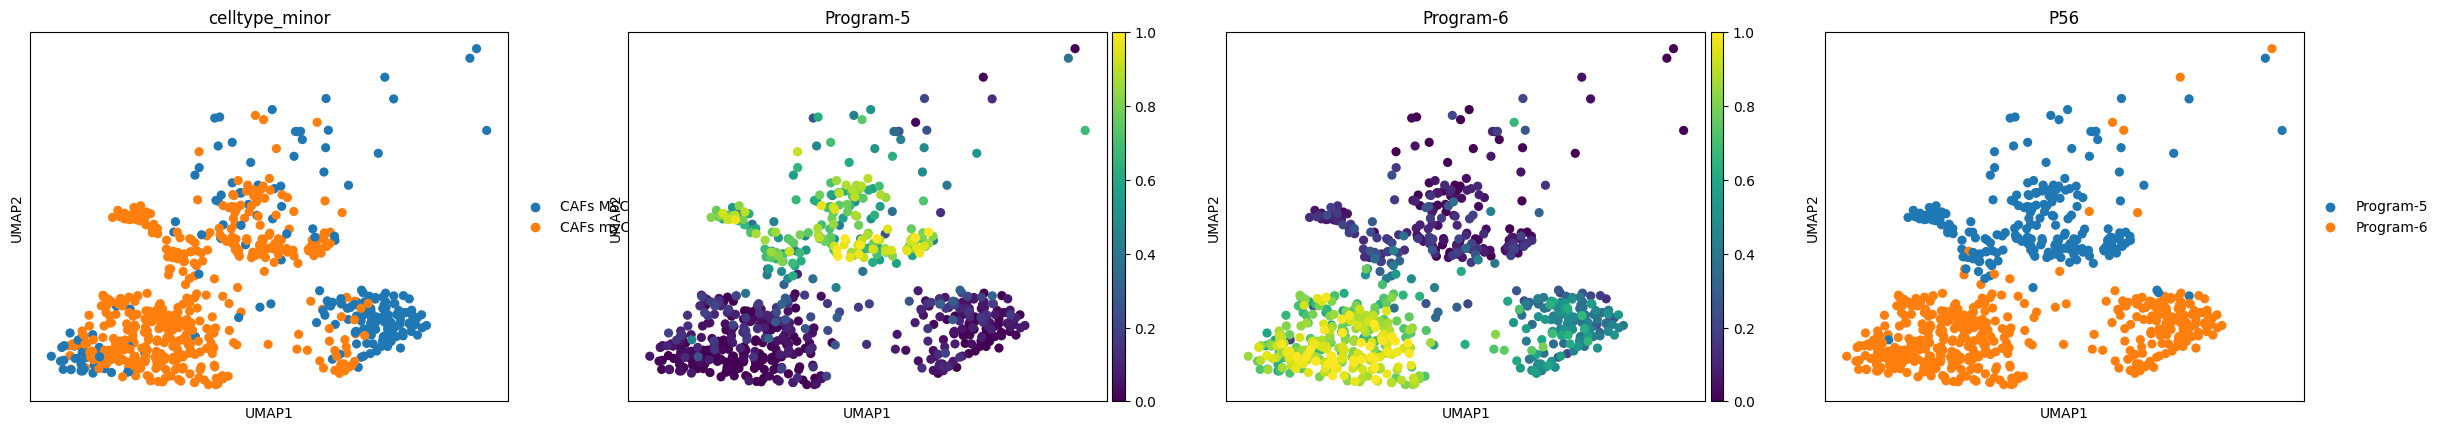

In [12]:
sc.pl.umap(adata, color=["celltype_minor", "Program-5", "Program-6", "P56"])